# 02 · Qual busca acha a regra certa?

**Objetivo:** escolher o modelo de embeddings do juiz com **dados**, não com palpite.

Cada modelo transforma os 496 trechos (166 do FAQ + 330 do CRD) em vetores. Depois, pra cada pergunta do [gabarito](../avaliacao/gabarito.yaml), olhamos se um trecho **que responde a pergunta** aparece entre os primeiros resultados.

| Métrica | O que mede |
|---|---|
| **hit@k** | em quantas perguntas (%) uma fonte certa aparece entre os *k* primeiros resultados |
| **MRR** | média de 1/posição da primeira fonte certa: 1,0 = sempre em 1º; 0,5 = em média em 2º |

Na etapa 5, o LLM vai receber os **5 primeiros** trechos, então **hit@5** é a métrica que mais importa: se a fonte certa não está entre eles, o LLM não tem como responder certo.

Os números vêm de `python -m juiz.avaliar_busca`, que salva as tabelas em `avaliacao/resultados/`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
resumo = pd.read_csv(RAIZ / "avaliacao" / "resultados" / "busca_resumo.csv")
detalhe = pd.read_csv(RAIZ / "avaliacao" / "resultados" / "busca_detalhe.csv")

NOMES = {
    "bm25": "BM25 (palavra-chave)",
    "e5-small": "multilingual-e5-small",
    "e5-base": "multilingual-e5-base",
    "qwen3-0.6b": "Qwen3-Embedding-0.6B",
    "gemini-2": "Gemini Embedding 2",
}
resumo["nome"] = resumo.modelo.map(NOMES)
print(f"{detalhe.id.nunique()} perguntas · {detalhe[detalhe.tem_resposta].id.nunique()} com resposta · modelos: {', '.join(resumo.modelo)}")

28 perguntas · 24 com resposta · modelos: bm25, e5-small, e5-base, gemini-2


## 1. Resultado geral

In [2]:
tabela = resumo.set_index("nome")[["hit@1", "hit@3", "hit@5", "mrr", "segundos_para_indexar", "ms_por_pergunta", "trechos_cortados"]]
tabela.style.format({"hit@1": "{:.0%}", "hit@3": "{:.0%}", "hit@5": "{:.0%}", "mrr": "{:.2f}",
                     "segundos_para_indexar": "{:.0f} s", "ms_por_pergunta": "{:.0f} ms",
                     "trechos_cortados": "{:.0f}"}, na_rep="—")

,hit@1,hit@3,hit@5,mrr,segundos_para_indexar,ms_por_pergunta,trechos_cortados
nome,,,,,,,
BM25 (palavra-chave),42%,54%,58%,0.49,0 s,—,—
multilingual-e5-small,88%,96%,100%,0.91,62 s,560 ms,3
multilingual-e5-base,79%,88%,92%,0.84,111 s,230 ms,3
Gemini Embedding 2,100%,100%,100%,1.00,256 s,102 ms,—


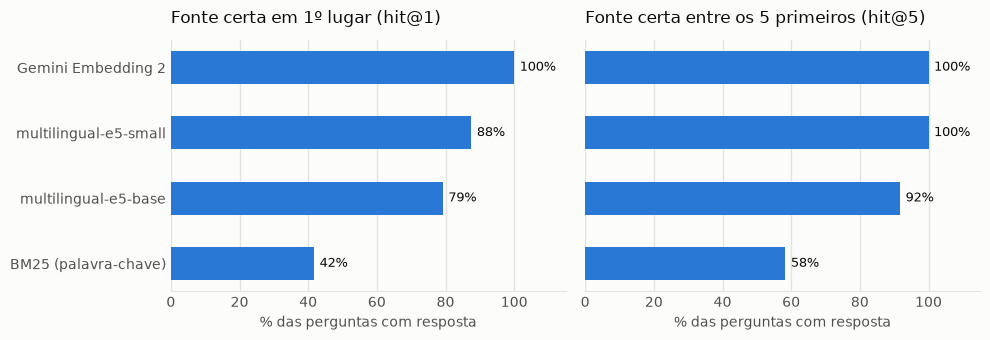

In [3]:
COR_SERIE, COR_SERIE_2 = "#2a78d6", "#eb6834"
COR_TEXTO, COR_TEXTO_2, COR_GRADE, COR_FUNDO = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"


def estilo_eixo(ax, titulo, rotulo_x):
    ax.set_facecolor(COR_FUNDO)
    ax.set_title(titulo, loc="left", color=COR_TEXTO, fontsize=12, pad=12)
    ax.set_xlabel(rotulo_x, color=COR_TEXTO_2)
    ax.tick_params(colors=COR_TEXTO_2, length=0)
    ax.xaxis.grid(True, color=COR_GRADE, linewidth=1)
    ax.set_axisbelow(True)
    for lado in ["top", "right", "left"]:
        ax.spines[lado].set_visible(False)
    ax.spines["bottom"].set_color(COR_GRADE)


# Dois painéis: hit@1 (fonte certa em 1º lugar) e hit@5 (entre os 5 primeiros).
dados = resumo.sort_values(["hit@5", "hit@1"])
fig, axes = plt.subplots(1, 2, figsize=(10, 0.5 * len(dados) + 1.5), facecolor=COR_FUNDO, sharey=True)
for ax, metrica, titulo in zip(axes, ["hit@1", "hit@5"], ["Fonte certa em 1º lugar (hit@1)", "Fonte certa entre os 5 primeiros (hit@5)"]):
    barras = ax.barh(dados.nome, dados[metrica] * 100, height=0.5, color=COR_SERIE)
    ax.bar_label(barras, labels=[f"{v:.0%}" for v in dados[metrica]], padding=4, color=COR_TEXTO, fontsize=9)
    ax.set_xlim(0, 115)
    estilo_eixo(ax, titulo, "% das perguntas com resposta")
plt.tight_layout()
plt.show()

## 2. Onde cada modelo erra: o jeito de perguntar importa?

As perguntas do gabarito têm três estilos: **formal**, **informal** ("se counterarem minha carta, recebo a mana de volta?") e com **termos do jogo em português** ("atordoar", "Emboscada").

In [4]:
por_estilo = resumo.set_index("nome")[["hit@5_formal", "hit@5_informal", "hit@5_termo_em_portugues"]]
por_estilo.columns = ["formal", "informal", "termo em português"]
por_estilo.style.format("{:.0%}")

,formal,informal,termo em português
nome,,,
BM25 (palavra-chave),56%,50%,71%
multilingual-e5-small,100%,100%,100%
multilingual-e5-base,89%,88%,100%
Gemini Embedding 2,100%,100%,100%


### Pergunta por pergunta

Posição em que a primeira fonte certa apareceu (1 = primeiro resultado; **—** = não apareceu entre os 10 primeiros).

In [5]:
com_resposta = detalhe[detalhe.tem_resposta].copy()
grade = com_resposta.pivot(index=["id", "pergunta"], columns="modelo", values="posicao")[resumo.modelo.tolist()]
grade.columns = [NOMES[m] for m in grade.columns]


def cor(v):
    if pd.isna(v):
        return "background-color: #f6d5d0"  # não achou
    return "background-color: #d7ecd9" if v <= 5 else "background-color: #fbe9c6"  # até 5º / depois do 5º


grade.style.format("{:.0f}", na_rep="—").map(cor)

,,BM25 (palavra-chave),multilingual-e5-small,multilingual-e5-base,Gemini Embedding 2
id,pergunta,,,,
q01,O Flash pode ter como alvo uma unidade que já está na base?,1,1,1,1
q02,Posso usar o Lacerate numa unidade com mais de 3 de força?,1,1,1,1
q03,O Switcheroo pode deixar uma unidade com might negativa?,4,1,1,1
q04,"Se o oponente counterar meu Sacrifice, a unidade que eu matei pra pagar volta?",2,1,1,1
q05,O Guardian Angel salva minha unidade do Smite?,1,1,1,1
q06,"A Irelia, Fervent ganha +1 de might quando é preparada na Awaken Phase?",1,1,1,1
q07,Por quanto tempo o Endless Riches me faz pular a fase de compra?,1,1,1,1
q08,"Quando a Vex, Apathetic atordoa a unidade que acabou de ser jogada, isso conta como escolher alvo?",1,1,1,1
q09,Preciso ter pontuado o Baron Pit pra ganhar a partida conquistando um battlefield?,3,1,1,1


## 3. Dá pra usar a nota de similaridade como "termômetro" do *não encontrei*?

Pra cada pergunta, olhamos a similaridade do **1º resultado**. Se as perguntas **sem resposta** (meta, preço, carta inventada, outro jogo) tiverem notas claramente menores, dá pra definir um corte: abaixo dele, o juiz responde "não encontrei" sem nem chamar o LLM.

O BM25 fica de fora aqui, porque a nota dele não é uma similaridade de 0 a 1.

> **Atenção ao ler o gráfico:** cada modelo tem sua própria escala no eixo horizontal, porque as notas de cada um ficam em faixas diferentes. O que importa é, **dentro de cada modelo**, se os pontos laranja (sem resposta) ficam separados dos azuis (com resposta).

In [6]:
emb = detalhe[detalhe.modelo != "bm25"].copy()
emb["grupo"] = emb.tem_resposta.map({True: "com resposta", False: "sem resposta"})
termometro = emb.groupby(["modelo", "grupo"]).nota_top1.agg(["min", "mean", "max"]).unstack("grupo")
termometro.index = [NOMES[m] for m in termometro.index]
termometro.round(3)

min                      mean               \
grupo                 com resposta sem resposta com resposta sem resposta   
multilingual-e5-base         0.803        0.777        0.850        0.798   
multilingual-e5-small        0.822        0.782        0.854        0.808   
Gemini Embedding 2           0.718        0.579        0.818        0.622   

                               max               
grupo                 com resposta sem resposta  
multilingual-e5-base         0.908        0.831  
multilingual-e5-small        0.903        0.846  
Gemini Embedding 2           0.880        0.675

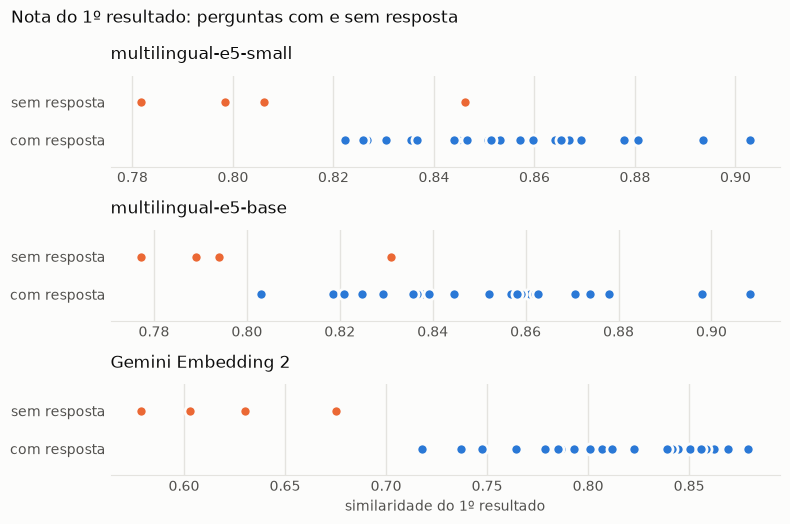

In [7]:
modelos = [m for m in resumo.modelo if m != "bm25"]
fig, axes = plt.subplots(len(modelos), 1, figsize=(8, 1.5 * len(modelos) + 0.8), facecolor=COR_FUNDO, sharex=False)
axes = [axes] if len(modelos) == 1 else axes
for ax, m in zip(axes, modelos):
    sub = emb[emb.modelo == m]
    for y, (grupo, cor_grupo) in enumerate([("com resposta", COR_SERIE), ("sem resposta", COR_SERIE_2)]):
        notas = sub[sub.grupo == grupo].nota_top1
        ax.scatter(notas, [y] * len(notas), s=64, color=cor_grupo, edgecolors=COR_FUNDO, linewidths=2, zorder=3)
    ax.set_yticks([0, 1], ["com resposta", "sem resposta"])
    ax.set_ylim(-0.7, 1.7)
    estilo_eixo(ax, NOMES[m], "")
axes[-1].set_xlabel("similaridade do 1º resultado", color=COR_TEXTO_2)
fig.suptitle("Nota do 1º resultado: perguntas com e sem resposta", x=0.02, ha="left", color=COR_TEXTO, fontsize=12)
plt.tight_layout()
plt.show()

## 4. Conclusões

**1. Embeddings multilíngues são indispensáveis.** O BM25 só achou a fonte certa entre os 5 primeiros em 58% das perguntas. Ele depende de palavras iguais, então só funciona quando a pergunta em português traz algum termo em inglês ("Smite", "Flow"). Perguntas como "Quando o showdown acaba?" ou "Se counterarem minha carta, recebo a mana de volta?" ficaram sem resposta.

**2. O Gemini Embedding 2 acertou tudo.** A fonte certa ficou em **1º lugar nas 24 perguntas** (hit@1 = 100%).

**3. O e5-small foi melhor que o e5-base.** Ele achou a fonte certa entre os 5 primeiros em todas as perguntas, mas em 3 delas ela só apareceu em 3º ou 4º lugar. O e5-base deixou 2 perguntas fora do top 5. Com só 24 perguntas, porém, 1 ou 2 perguntas de diferença (4 a 8 pontos percentuais) **pode ser acaso**. O que dá pra afirmar é que os dois e5 ficam claramente abaixo do Gemini e claramente acima do BM25.

**4. Só o Gemini serve de "termômetro" pro *não encontrei*.**
- No Gemini, a maior nota entre as perguntas sem resposta foi **0,675**, e a menor entre as com resposta foi **0,718**. Um corte perto de 0,70 separaria os dois grupos.
- Nos e5, as notas ficam todas espremidas entre 0,78 e 0,91, e os grupos se misturam. Se o modelo escolhido for um e5, o "não encontrei" vai depender só do LLM.

**Cuidados antes de generalizar:**
- **Amostra pequena:** são 24 perguntas com resposta e só 4 sem resposta. A etapa 7 vai ampliar o gabarito.
- **Possível viés:** as perguntas foram escritas olhando os trechos, o que pode deixar a busca mais fácil do que as perguntas de um jogador de verdade.
- **O corte de 0,70 é um candidato, não uma regra.** Ele precisa ser confirmado com mais perguntas fora do escopo.

**Outros fatores, além da qualidade:**

| | Gemini Embedding 2 | multilingual-e5-small |
|---|---|---|
| Custo | tier grátis (com limite de uso) | grátis, pra sempre |
| Privacidade | as perguntas vão pro Google, que usa os dados pra melhorar produtos | tudo roda local |
| Deploy | leve: o app só chama a API | o modelo roda no servidor (cabe no Streamlit Cloud) |
| Dependência | precisa de internet, chave e das regras do tier grátis | nenhuma |
| Indexação | ~4 min (limite de uso do tier grátis) | ~1 min |